# Data & Imports

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import kagglehub
from kagglehub import KaggleDatasetAdapter


In [45]:
file_path = "Walmart_Sales.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mikhail1681/walmart-sales",
  file_path,
)

df.to_csv('./data/Walmart_Sales.csv', index=False)

df = pd.read_csv("data/Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [46]:
df.drop_duplicates(inplace=True)

# Data Cleaning

In [47]:
df['Date'] = pd.to_datetime(df['Date'],format="%d-%m-%Y")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter


df.drop('Date',axis=1, inplace=True)

In [48]:
df= df[['Year', 'Month','Week','Quarter','Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekly_Sales']]

In [49]:
df.head()

,Year,Month,Week,Quarter,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales
0,2010,2,5,1,1,0,42.31,2.572,211.096358,8.106,1643690.90
1,2010,2,6,1,1,1,38.51,2.548,211.242170,8.106,1641957.44
2,2010,2,7,1,1,0,39.93,2.514,211.289143,8.106,1611968.17
3,2010,2,8,1,1,0,46.63,2.561,211.319643,8.106,1409727.59
4,2010,3,9,1,1,0,46.50,2.625,211.350143,8.106,1554806.68


### Save Cleaned data copy

In [50]:
df.to_csv("./data/Walmart_Sales_Cleaned.csv",index=False)

# EDA


### Weekly Sales Distribution

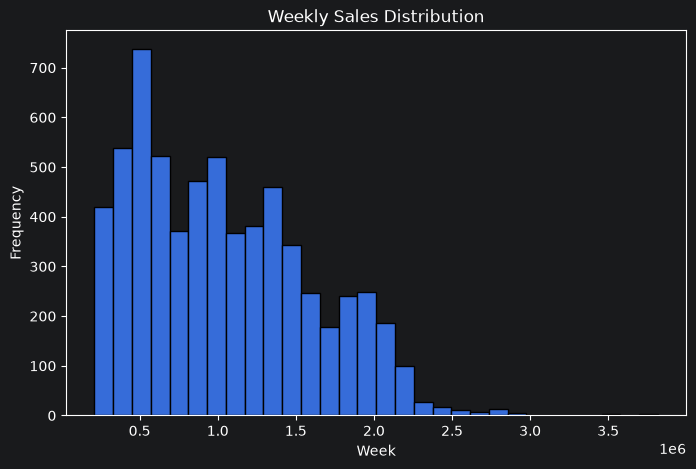

In [51]:
plt.figure(figsize=(8,5))
plt.hist(df['Weekly_Sales'],bins=30, edgecolor='black')
plt.xlabel('Week')
plt.ylabel('Frequency')
plt.title('Weekly Sales Distribution')
plt.savefig("images/weekly_sales_distribution.png",dpi=300,bbox_inches='tight')
plt.show()

### Boxplot (Outliers)

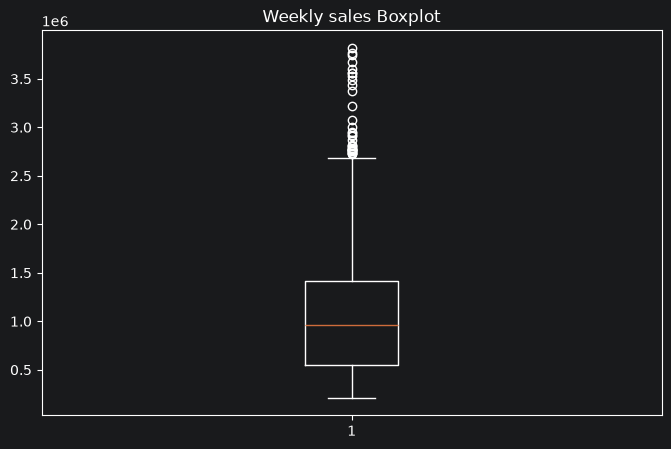

In [52]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Weekly_Sales"])
plt.title('Weekly sales Boxplot')
plt.savefig("images/Weekly_sales_Boxplot.png",dpi=300,bbox_inches='tight')
plt.show()

### Temperature vs Weekly Sales

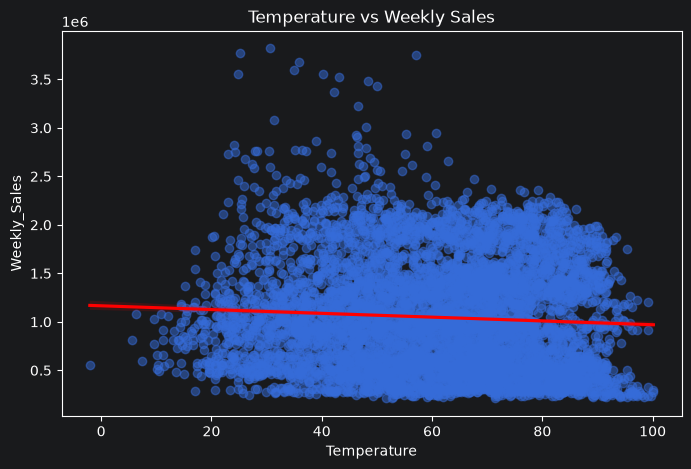

In [53]:
plt.figure(figsize=(8,5))
sns.regplot(
    data = df,
    x = 'Temperature',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Temperature vs Weekly Sales')
plt.savefig("images/Temperature_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Fuel Price vs Weekly Sales

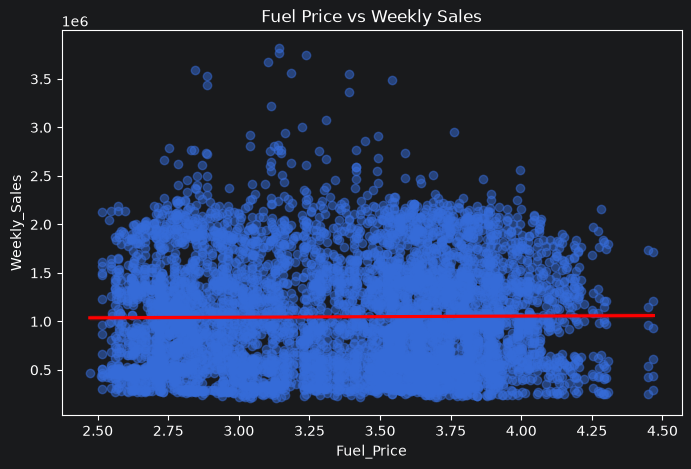

In [54]:
plt.figure(figsize=(8,5))

sns.regplot(
    data = df,
    x = 'Fuel_Price',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Fuel Price vs Weekly Sales')

plt.savefig("images/Fuel_Price_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### CPI vs Weekly Sales

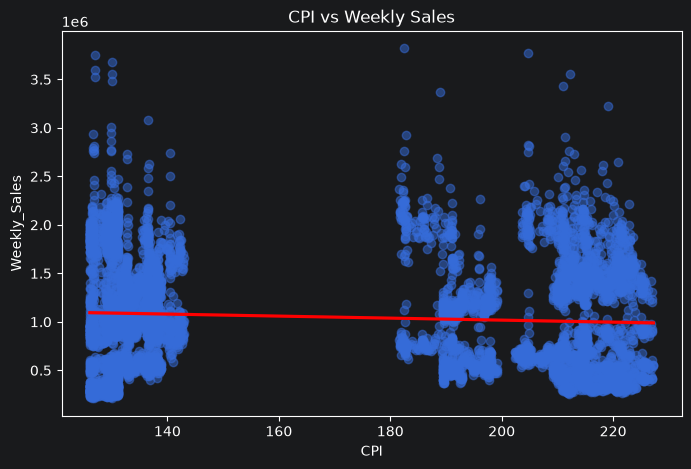

In [55]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data = df,
    x = 'CPI',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('CPI vs Weekly Sales')
plt.savefig("images/CPI_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Unemployment vs Weekly Sales

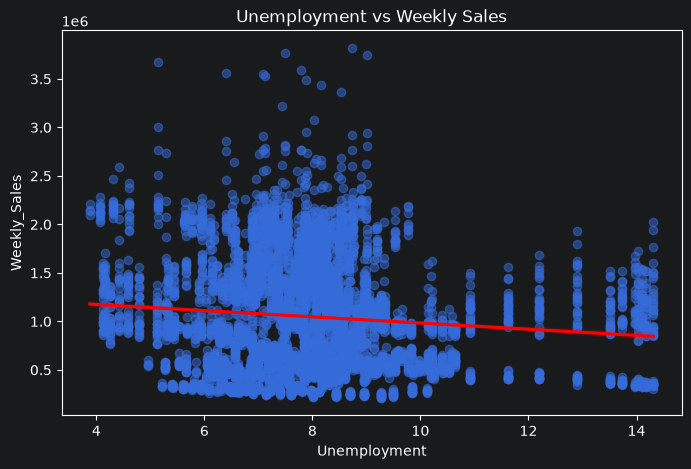

In [56]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data = df,
    x = 'Unemployment',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Unemployment vs Weekly Sales')
plt.savefig("images/Unemployment_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Holiday vs Weekly Sales

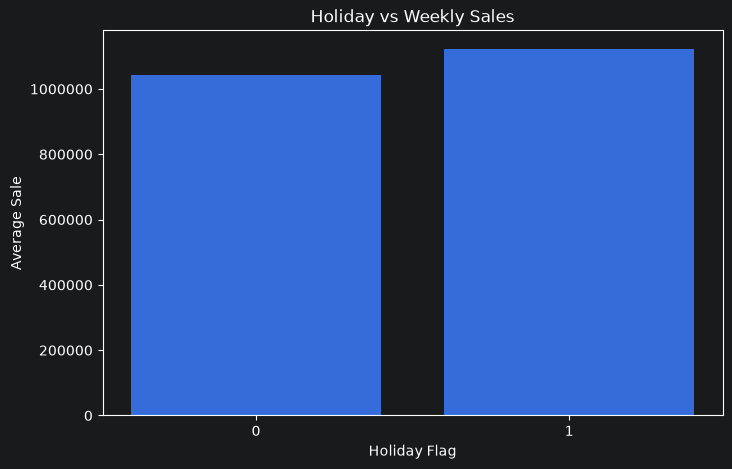

In [57]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
plt.figure(figsize=(8,5))
plt.bar(
    holiday_sales.index.astype(str),
    holiday_sales.values
)
plt.title('Holiday vs Weekly Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Holiday_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Monthly Sales Trend

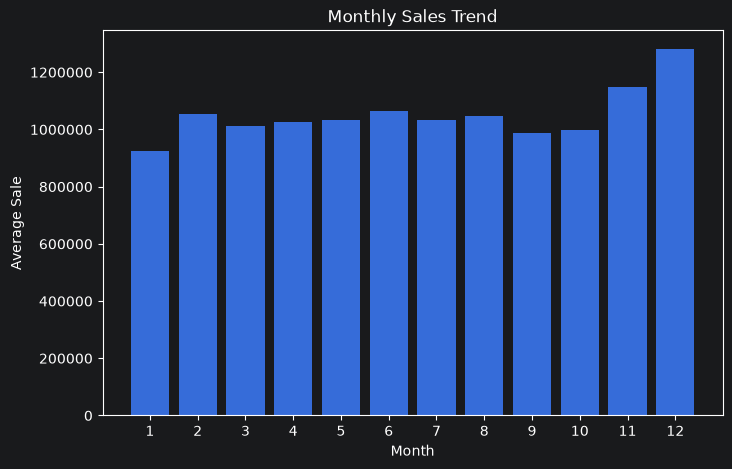

In [58]:
monthly_sales = df.groupby('Month')["Weekly_Sales"].mean()

plt.figure(figsize=(8,5))
plt.bar(
    monthly_sales.index.astype(str),
    monthly_sales.values,
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Monthly_Sales_Trend.png",dpi=300,bbox_inches='tight')
plt.show()

### Store Wise Sales

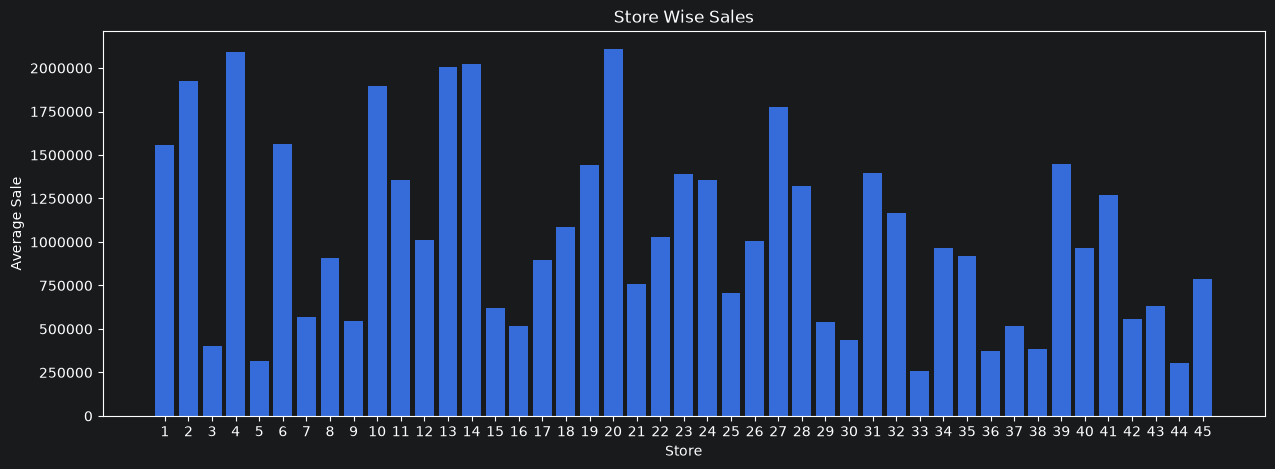

In [59]:
store_sales = df.groupby('Store')["Weekly_Sales"].mean()

plt.figure(figsize=(15,5))
plt.bar(
    store_sales.index.astype(str),
    store_sales.values
)
plt.title('Store Wise Sales')
plt.xlabel('Store')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Store_Wise_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

## Heatmap

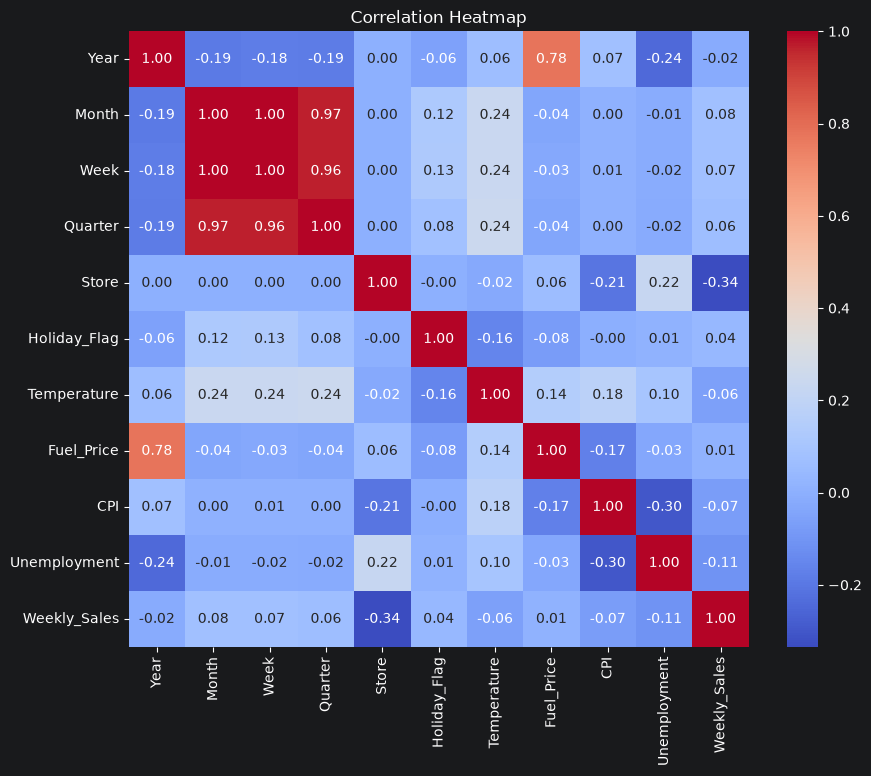

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('Correlation Heatmap')
plt.savefig("images/Heatmap.png",dpi=300,bbox_inches='tight')
plt.show()

## Feature Selection

In [61]:
target = df['Weekly_Sales']

features = df[['Year', 'Week', 'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

## Import

In [62]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.model_selection import (KFold,cross_validate,RandomizedSearchCV)
from xgboost import XGBRegressor

from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)
import joblib

### Train-Test-Split

In [63]:
x_train,x_test,y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=42)

### Standardization

In [64]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [65]:
## Saving Scaler
joblib.dump(scaler,"./model/scaler.pkl")

['./model/scaler.pkl']

## Linear Regression

In [66]:
lr = LinearRegression()

## Lasso Regression

In [67]:
ls = Lasso(
    alpha=0.1,
    random_state=42
)

## XG Boost

In [68]:
xg = XGBRegressor(
    random_state=42
)

## Cross Validation

In [69]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'R2':'r2',
    'MAE':'neg_mean_absolute_error',
    'RMSE':'neg_root_mean_squared_error'
}

In [70]:
def cross_validation(model,x,y):
    scores = cross_validate(
        model,
        x,
        y,
        cv = cv,
        scoring = scoring
    )

    print("Avg R2: ",scores["test_R2"].mean())
    print("Avg MAE: ",-scores["test_MAE"].mean())
    print("Avg RMSE: ",-scores["test_RMSE"].mean())

In [71]:
# Linear Regression
cross_validation(
    lr,
    x_train_scaled,
    y_train,
)

Avg R2:  0.1424891928136167
Avg MAE:  429856.202417713
Avg RMSE:  521634.7255302303


In [72]:
# Lasso Regression
cross_validation(
    ls,
    x_train_scaled,
    y_train
)

Avg R2:  0.14248919446652364
Avg MAE:  429856.19857944536
Avg RMSE:  521634.7250806773


In [73]:
# XG Boost
cross_validation(
    xg,
    x_train,
    y_train
)

Avg R2:  0.9737453401255196
Avg MAE:  51887.92192251326
Avg RMSE:  90185.22120240534


## Hyperparameter Tuning with RandomizedSearchCV

In [74]:
params={
    "n_estimators":[100,200,300,400,500],
    "max_depth":[3,5,7,9],
    "learning_rate":[0.01,0.02,0.05,0.1,0.2],
    "subsample":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0]
}

random_search = RandomizedSearchCV(
    estimator = xg,
    param_distributions= params,
    n_iter= 20,
    scoring= 'r2',
    cv = 5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function which

In [75]:
best_model = random_search.best_estimator_

print("Best Parameters: ")
print(random_search.best_params_)

print("\nBest Cross Validation R²: ")
print(random_search.best_score_)

Best Parameters: 
{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best Cross Validation R²: 
0.9763458527972823


In [76]:
from xgboost import plot_importance

<Figure size 1000x600 with 0 Axes>

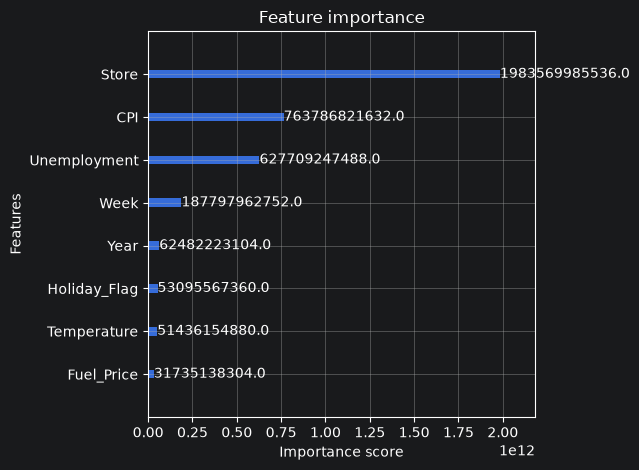

In [77]:
plt.figure(figsize=(10,6))

plot_importance( best_model,importance_type="gain")

plt.tight_layout()
plt.savefig( "images/Feature_Importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [78]:
y_pred = best_model.predict(x_test)

## Save Model

In [79]:
joblib.dump(best_model,"./model/XGBoost_model.pkl")

['./model/XGBoost_model.pkl']

## Actual vs Predicted

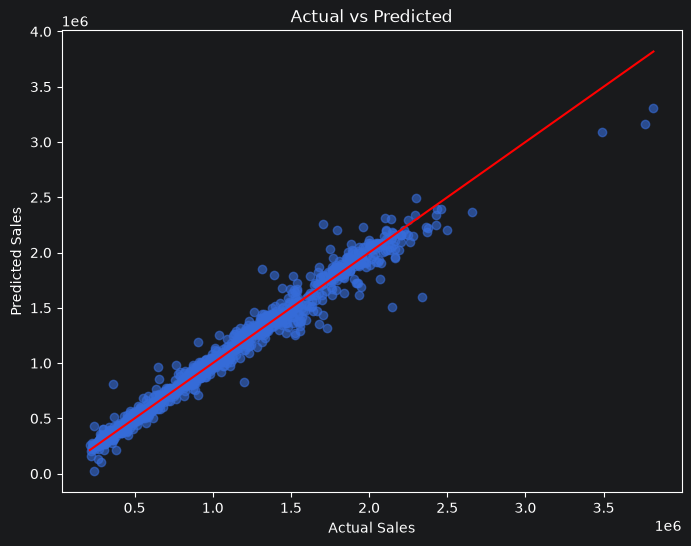

In [80]:
plt.figure(figsize=(8,6))

plt.scatter( y_test, y_pred, alpha=0.6)
plt.plot( [y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.savefig("images/Actual_vs_Predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluation

In [81]:
def evaluate(y_test,y_pred):
    print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
    print(f"MSE : {mean_squared_error(y_test,y_pred)}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}")
    print(f"R² : {r2_score(y_test,y_pred)}")


In [82]:
evaluate(y_test,y_pred)

MAE : 50798.88219059586
MSE : 7057339151.272062
RMSE : 84007.97076035144
R² : 0.9780933131917725


### Residual Plot

In [83]:
residuals = y_test-y_pred

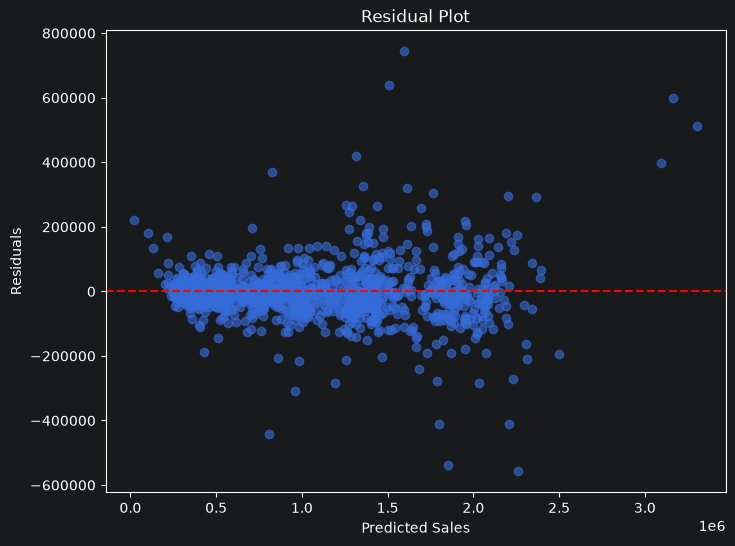

In [84]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals,alpha=0.6)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.savefig("./images/Residual_plot.png",dpi=300,bbox_inches='tight')
plt.show()

## Conclusion